# MAISON-LLF Leakage-Safe Temporal Forecasting

This notebook predicts future SIS and OHS questionnaire items from cumulative wearable history. Each assessment becomes one example; its sensor history ends `FORECAST_GAP_DAYS` before the future `clinical-timestamp`, so sensor rows on or after the prediction horizon never enter the model.

The primary model is a small multi-task GRU with masked variable-length batches, target-specific SHAP-initialized feature gates, and attention logits biased by exponential recency decay. The decay prior favors recent days while attention remains learnable and visualizable. Patient-group splits test generalization to unseen people.

## Setup

In [1]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

SEED = 2026
FORECAST_GAP_DAYS = 7
BATCH_SIZE = 12
N_FOLDS = 5
MAX_EPOCHS = 300
PATIENCE = 45
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM = 48
DROPOUT = 0.15
DECAY_RATE = 0.08
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
plt.style.use("ggplot")
DATA_DIR = Path.cwd()
FEATURES_CSV = DATA_DIR / "maison-llf-features.csv"
SIS_SHAP_CSV = DATA_DIR / "shap_sis_feature_importance.csv"
OHS_SHAP_CSV = DATA_DIR / "shap_ohs_feature_importance.csv"
DEVICE

device(type='cpu')

## Data Contract and Features

In [2]:
raw = pd.read_csv(FEATURES_CSV, parse_dates=["timestamp", "clinical-timestamp"])
raw = raw.sort_values(["participant", "timestamp", "clinical-timestamp"]).reset_index(drop=True)
sis_targets = [f"sis-{i:02d}" for i in range(1, 7)]
ohs_targets = [f"ohs-{i:02d}" for i in range(1, 13)]
target_cols = sis_targets + ohs_targets
clinical_cols = target_cols + ["sis", "ohs", "oks", "tug", "chairstand"] + [f"oks-{i:02d}" for i in range(1, 13)]
id_cols = ["participant", "timestamp", "clinical-timestamp"]
sensor_cols = [c for c in raw.columns if c not in id_cols + clinical_cols]
time_cols = ["days_since_start", "dow_sin", "dow_cos"]
input_cols = sensor_cols + time_cols

assert set(sis_targets + ohs_targets).issubset(raw.columns)
assert not set(sensor_cols).intersection(clinical_cols)
print(f"rows={len(raw)}, patients={raw['participant'].nunique()}, sensors={len(sensor_cols)}")
print(f"targets: SIS={len(sis_targets)} items, OHS={len(ohs_targets)} items")
print(sensor_cols)

rows=1008, patients=18, sensors=46
targets: SIS=6 items, OHS=12 items
['acceleration-count', 'acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-kurtosis', 'acceleration-skew', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-movement-events-24h', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-min', 'heartrate-max', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-ratio', 'motion-mean', 'motion-max', 'motion-max-timestamp', 'position-count', 'position-duration', 'position-distance-travelled', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'sleep-wakeup-count', 'sleep-heartrat

SHAP files use dataset-native names such as `sleep-snoring` and `position-distance-travelled`. Every available sensor column is retained; SHAP weights initialize feature gates where weights exist, while unlisted sensors receive a small positive prior and remain learnable.

In [3]:
def load_feature_prior(path, sensor_columns, floor=0.02):
    shap = pd.read_csv(path).dropna(subset=["feature"])
    weights = shap.set_index("feature")["weights"].astype(float).to_dict()
    prior = np.array([weights.get(c, floor) for c in sensor_columns], dtype=np.float32)
    prior = prior / prior.mean()
    return prior, shap

sis_sensor_prior, sis_shap = load_feature_prior(SIS_SHAP_CSV, sensor_cols)
ohs_sensor_prior, ohs_shap = load_feature_prior(OHS_SHAP_CSV, sensor_cols)
sis_feature_prior = np.r_[sis_sensor_prior, np.ones(len(time_cols), dtype=np.float32)]
ohs_feature_prior = np.r_[ohs_sensor_prior, np.ones(len(time_cols), dtype=np.float32)]
pd.DataFrame({"feature": sensor_cols, "sis_prior": sis_sensor_prior, "ohs_prior": ohs_sensor_prior}).sort_values("sis_prior", ascending=False).head(10)

,feature,sis_prior,ohs_prior
1,acceleration-mean,3.847972,7.295398
31,sleep-deep,3.183513,3.647503
34,sleep-snoring,2.950619,1.020264
35,sleep-duration-to-sleep,2.355552,0.608310
32,sleep-light,2.134066,0.668395
40,sleep-heartrate-max,1.863149,0.594958
24,motion-mean,1.457248,3.518694
22,motion-count,1.415423,0.575000
39,sleep-heartrate-min,1.354585,0.575000
19,heartrate-mean,1.346030,0.575000


## Future Forecast Examples

In [4]:
def add_time_features(history):
    history = history.copy()
    start = history["timestamp"].min()
    history["days_since_start"] = (history["timestamp"] - start).dt.days.astype(float)
    dow = history["timestamp"].dt.dayofweek.astype(float)
    history["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    history["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    return history

def build_forecast_examples(frame, gap_days):
    examples = []
    for patient, patient_df in frame.groupby("participant", sort=True):
        patient_df = patient_df.sort_values("timestamp")
        for clinical_time, assessment_rows in patient_df.groupby("clinical-timestamp", sort=True):
            cutoff = clinical_time - pd.Timedelta(days=gap_days)
            history = patient_df.loc[patient_df["timestamp"] <= cutoff].copy()
            if history.empty:
                continue
            history = add_time_features(history)
            target_row = assessment_rows.iloc[0]
            examples.append({
                "patient": patient,
                "clinical_time": clinical_time,
                "cutoff": cutoff,
                "timestamps": history["timestamp"].to_numpy(),
                "x_frame": history[input_cols].copy(),
                "sis": target_row[sis_targets].astype(float).to_numpy(),
                "ohs": target_row[ohs_targets].astype(float).to_numpy(),
                "sis_total": float(target_row["sis"]),
                "ohs_total": float(target_row["ohs"]),
            })
    return examples

examples = build_forecast_examples(raw, FORECAST_GAP_DAYS)
example_index = pd.DataFrame([{k: e[k] for k in ["patient", "clinical_time", "cutoff"]} | {"history_days": len(e["timestamps"])} for e in examples])
assert all(pd.Timestamp(e["timestamps"].max()) <= e["cutoff"] < e["clinical_time"] for e in examples)
assert example_index.groupby("patient")["history_days"].apply(list).eq([[7, 21, 35, 49]] * raw["participant"].nunique()).all()
example_index.head(8)

,patient,clinical_time,cutoff,history_days
0,1,2022-04-13,2022-04-06,7
1,1,2022-04-27,2022-04-20,21
2,1,2022-05-11,2022-05-04,35
3,1,2022-05-25,2022-05-18,49
4,2,2022-10-28,2022-10-21,7
5,2,2022-11-11,2022-11-04,21
6,2,2022-11-25,2022-11-18,35
7,2,2022-12-09,2022-12-02,49


Each target is predicted from a growing history with a strict one-week forecast gap. For the first patient this gives 7, 21, 35, and 49 input days for the four future assessments.

## Patient-Grouped Cross-Validation, Imputation, and Normalization

In [5]:
all_patients = np.array(sorted(example_index["patient"].unique()))
rng = np.random.default_rng(SEED)
shuffled_patients = all_patients.copy()
rng.shuffle(shuffled_patients)
test_patient_folds = [np.array(fold, dtype=int) for fold in np.array_split(shuffled_patients, N_FOLDS)]

def ids_for_patients(patients):
    return np.flatnonzero(example_index["patient"].isin(patients).to_numpy())

def patients_for(ids):
    return sorted(example_index.iloc[ids]["patient"].unique().tolist())

cv_folds = []
for fold_id, test_patients in enumerate(test_patient_folds, start=1):
    val_patients = test_patient_folds[fold_id % N_FOLDS]
    train_patients = np.array([p for p in all_patients if p not in set(test_patients).union(set(val_patients))], dtype=int)
    train_ids = ids_for_patients(train_patients)
    val_ids = ids_for_patients(val_patients)
    test_ids = ids_for_patients(test_patients)
    assert set(patients_for(train_ids)).isdisjoint(patients_for(val_ids) + patients_for(test_ids))
    cv_folds.append({"fold": fold_id, "train_ids": train_ids, "val_ids": val_ids, "test_ids": test_ids})

def compute_train_stats(ids):
    train_frames = pd.concat([examples[i]["x_frame"] for i in ids], ignore_index=True)
    median = train_frames.median(numeric_only=True).reindex(input_cols).fillna(0.0)
    imputed = train_frames.reindex(columns=input_cols).fillna(median)
    mean = imputed.mean().reindex(input_cols)
    std = imputed.std(ddof=0).reindex(input_cols).replace(0, 1.0).fillna(1.0)
    return {"median": median, "mean": mean, "std": std}

def transform_inputs(x_frame, stats):
    x = x_frame.reindex(columns=input_cols).fillna(stats["median"])
    return ((x - stats["mean"]) / stats["std"]).astype(np.float32).to_numpy()

fold_table = pd.DataFrame([
    {
        "fold": f["fold"],
        "train_patients": patients_for(f["train_ids"]),
        "val_patients": patients_for(f["val_ids"]),
        "test_patients": patients_for(f["test_ids"]),
        "train_examples": len(f["train_ids"]),
        "val_examples": len(f["val_ids"]),
        "test_examples": len(f["test_ids"]),
    }
    for f in cv_folds
])
fold_table

,fold,train_patients,val_patients,test_patients,train_examples,val_examples,test_examples
0,1,"[4, 5, 6, 8, 9, 11, 14, 15, 16, 18]","[1, 3, 10, 17]","[2, 7, 12, 13]",40,16,16
1,2,"[2, 5, 6, 7, 8, 11, 12, 13, 16, 18]","[4, 9, 14, 15]","[1, 3, 10, 17]",40,16,16
2,3,"[1, 2, 3, 5, 7, 10, 11, 12, 13, 16, 17]","[6, 8, 18]","[4, 9, 14, 15]",44,12,16
3,4,"[1, 2, 3, 4, 7, 9, 10, 12, 13, 14, 15, 17]","[5, 11, 16]","[6, 8, 18]",48,12,12
4,5,"[1, 3, 4, 6, 8, 9, 10, 14, 15, 17, 18]","[2, 7, 12, 13]","[5, 11, 16]",44,16,12


Missing values are median-imputed from each fold's training histories only, and input channels are standardized with that fold's training-history statistics only. Validation and test patients never influence either transform.

## Variable-Length Batches

In [6]:
class ForecastDataset(Dataset):
    def __init__(self, records, ids, stats):
        self.records = [records[i] for i in ids]
        self.stats = stats

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        e = self.records[idx]
        x = transform_inputs(e["x_frame"], self.stats)
        return {
            "x": torch.tensor(x.tolist(), dtype=torch.float32),
            "sis": torch.tensor(e["sis"].tolist(), dtype=torch.float32),
            "ohs": torch.tensor(e["ohs"].tolist(), dtype=torch.float32),
            "patient": e["patient"],
            "clinical_time": e["clinical_time"],
            "timestamps": e["timestamps"],
        }

def collate_forecasts(batch):
    lengths = torch.tensor([len(b["x"]) for b in batch], dtype=torch.long)
    max_len = int(lengths.max())
    x = torch.zeros(len(batch), max_len, len(input_cols), dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        x[i, : lengths[i]] = b["x"]
        mask[i, : lengths[i]] = True
    return {
        "x": x,
        "mask": mask,
        "lengths": lengths,
        "sis": torch.stack([b["sis"] for b in batch]),
        "ohs": torch.stack([b["ohs"] for b in batch]),
        "patient": [b["patient"] for b in batch],
        "clinical_time": [b["clinical_time"] for b in batch],
        "timestamps": [b["timestamps"] for b in batch],
    }

def make_loader(ids, stats, shuffle):
    return DataLoader(ForecastDataset(examples, ids, stats), batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=collate_forecasts)

preview_stats = compute_train_stats(cv_folds[0]["train_ids"])
preview_loader = make_loader(cv_folds[0]["train_ids"], preview_stats, shuffle=True)
batch = next(iter(preview_loader))
{k: tuple(v.shape) for k, v in batch.items() if torch.is_tensor(v)}

{'x': (12, 49, 49),
 'mask': (12, 49),
 'lengths': (12,),
 'sis': (12, 6),
 'ohs': (12, 12)}

## Feature-Gated GRU With Recency-Biased Attention

In [7]:
def inverse_softplus(x):
    x = torch.tensor(np.asarray(x).tolist(), dtype=torch.float32).clamp_min(1e-4)
    return torch.log(torch.expm1(x))

class FeatureGate(nn.Module):
    def __init__(self, prior):
        super().__init__()
        self.raw = nn.Parameter(inverse_softplus(prior))

    def forward(self, x):
        weights = torch.nn.functional.softplus(self.raw)
        weights = weights / weights.mean().clamp_min(1e-6)
        return x * weights, weights

class DecayAttention(nn.Module):
    def __init__(self, hidden_dim, decay_rate):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
        self.raw_decay = nn.Parameter(inverse_softplus(np.array([decay_rate], dtype=np.float32)))

    def forward(self, encoded, mask, lengths):
        steps = torch.arange(encoded.size(1), device=encoded.device).unsqueeze(0)
        age = (lengths.to(encoded.device).unsqueeze(1) - 1 - steps).clamp_min(0).float()
        decay = torch.nn.functional.softplus(self.raw_decay)
        logits = self.score(encoded).squeeze(-1) - decay * age
        logits = logits.masked_fill(~mask, -torch.finfo(encoded.dtype).max)
        attention = torch.softmax(logits, dim=1)
        context = torch.bmm(attention.unsqueeze(1), encoded).squeeze(1)
        return context, attention, decay

class MaisonTemporalForecaster(nn.Module):
    def __init__(self, n_features, sis_prior, ohs_prior, hidden_dim, dropout, decay_rate):
        super().__init__()
        self.sis_gate = FeatureGate(sis_prior)
        self.ohs_gate = FeatureGate(ohs_prior)
        self.input_projection = nn.Sequential(nn.Linear(n_features * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout))
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.sis_attention = DecayAttention(hidden_dim, decay_rate)
        self.ohs_attention = DecayAttention(hidden_dim, decay_rate)
        self.sis_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, len(sis_targets)))
        self.ohs_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, len(ohs_targets)))

    def forward(self, x, mask, lengths):
        sis_x, sis_weights = self.sis_gate(x)
        ohs_x, ohs_weights = self.ohs_gate(x)
        projected = self.input_projection(torch.cat([sis_x, ohs_x], dim=-1))
        packed = pack_padded_sequence(projected, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_encoded, _ = self.gru(packed)
        encoded, _ = pad_packed_sequence(packed_encoded, batch_first=True, total_length=x.size(1))
        sis_context, sis_attention, sis_decay = self.sis_attention(encoded, mask, lengths)
        ohs_context, ohs_attention, ohs_decay = self.ohs_attention(encoded, mask, lengths)
        return {
            "sis": self.sis_head(sis_context),
            "ohs": self.ohs_head(ohs_context),
            "sis_attention": sis_attention,
            "ohs_attention": ohs_attention,
            "sis_feature_weights": sis_weights,
            "ohs_feature_weights": ohs_weights,
            "sis_decay": sis_decay,
            "ohs_decay": ohs_decay,
        }

def make_model():
    return MaisonTemporalForecaster(len(input_cols), sis_feature_prior, ohs_feature_prior, HIDDEN_DIM, DROPOUT, DECAY_RATE).to(DEVICE)

preview_model = make_model()
sum(p.numel() for p in preview_model.parameters() if p.requires_grad)

24936

The sequences are padded only inside a batch and masks remove padded days from attention. The GRU consumes packed lengths, so padding does not update recurrent state. SHAP priors enter as positive trainable feature gates. Attention combines learned content logits with a learned exponential recency penalty `-decay * age_in_days`.

## Cross-Validation Training

In [8]:
loss_fn = nn.SmoothL1Loss()

def move_batch(batch):
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}

def multitask_loss(output, batch):
    return loss_fn(output["sis"], batch["sis"]) + loss_fn(output["ohs"], batch["ohs"])

def run_epoch(model, optimizer, loader, training):
    model.train(training)
    total = 0.0
    n = 0
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(training):
            output = model(batch["x"], batch["mask"], batch["lengths"])
            loss = multitask_loss(output, batch)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total += loss.item() * len(batch["x"])
        n += len(batch["x"])
    return total / n

def train_one_fold(fold):
    seed_everything(SEED + fold["fold"])
    stats = compute_train_stats(fold["train_ids"])
    train_loader = make_loader(fold["train_ids"], stats, shuffle=True)
    val_loader = make_loader(fold["val_ids"], stats, shuffle=False)
    model = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    wait = 0
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, optimizer, train_loader, training=True)
        val_loss = run_epoch(model, optimizer, val_loader, training=False)
        history.append({"fold": fold["fold"], "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    sis_decay = torch.nn.functional.softplus(model.sis_attention.raw_decay.detach()).item()
    ohs_decay = torch.nn.functional.softplus(model.ohs_attention.raw_decay.detach()).item()
    return {
        "fold": fold["fold"],
        "model": model,
        "stats": stats,
        "train_ids": fold["train_ids"],
        "val_ids": fold["val_ids"],
        "test_ids": fold["test_ids"],
        "history": pd.DataFrame(history),
        "best_val": best_val,
        "epochs": len(history),
        "sis_decay": sis_decay,
        "ohs_decay": ohs_decay,
    }

cv_artifacts = []
for fold in cv_folds:
    artifact = train_one_fold(fold)
    cv_artifacts.append(artifact)
    print(f"fold {artifact['fold']}: epochs={artifact['epochs']}, best_val={artifact['best_val']:.4f}, SIS decay={artifact['sis_decay']:.4f}, OHS decay={artifact['ohs_decay']:.4f}")

history_df = pd.concat([a["history"] for a in cv_artifacts], ignore_index=True)
cv_training_summary = pd.DataFrame([{k: a[k] for k in ["fold", "epochs", "best_val", "sis_decay", "ohs_decay"]} for a in cv_artifacts])
display(cv_training_summary)

fold 1: epochs=53, best_val=1.0385, SIS decay=0.0772, OHS decay=0.0768


fold 2: epochs=56, best_val=1.4128, SIS decay=0.0771, OHS decay=0.0760


fold 3: epochs=54, best_val=0.9223, SIS decay=0.0807, OHS decay=0.0754


fold 4: epochs=58, best_val=1.3387, SIS decay=0.0753, OHS decay=0.0775


fold 5: epochs=53, best_val=1.1267, SIS decay=0.0777, OHS decay=0.0775


,fold,epochs,best_val,sis_decay,ohs_decay
0,1,53,1.038538,0.077206,0.076808
1,2,56,1.412815,0.077090,0.076029
2,3,54,0.922285,0.080676,0.075398
3,4,58,1.338657,0.075284,0.077454
4,5,53,1.126747,0.077716,0.077495


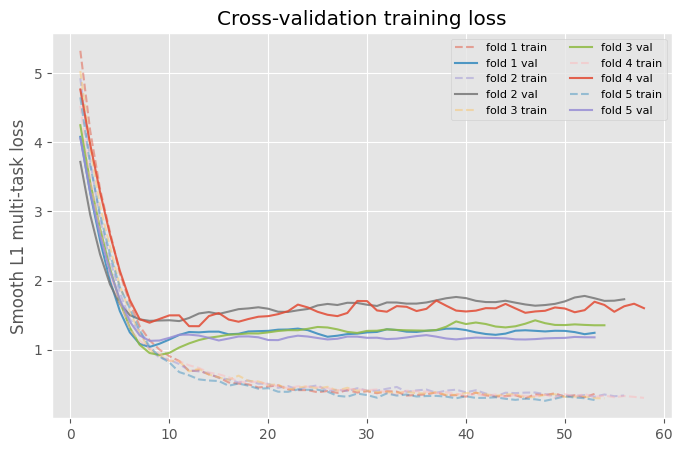

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for fold, fold_history in history_df.groupby("fold"):
    ax.plot(fold_history["epoch"], fold_history["train_loss"], alpha=0.45, linestyle="--", label=f"fold {fold} train")
    ax.plot(fold_history["epoch"], fold_history["val_loss"], alpha=0.85, label=f"fold {fold} val")
ax.set_ylabel("Smooth L1 multi-task loss")
ax.set_title("Cross-validation training loss")
ax.legend(ncol=2, fontsize=8)
plt.show()

## Evaluation

In [10]:
def collect_predictions(model, loader, fold_id):
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            device_batch = move_batch(batch)
            output = model(device_batch["x"], device_batch["mask"], device_batch["lengths"])
            sis_pred = output["sis"].cpu().tolist()
            ohs_pred = output["ohs"].cpu().tolist()
            for i in range(len(batch["patient"])):
                base = {"fold": fold_id, "patient": batch["patient"][i], "clinical_time": pd.Timestamp(batch["clinical_time"][i]), "history_days": int(batch["lengths"][i])}
                for name, truth, pred in zip(sis_targets, batch["sis"][i].tolist(), sis_pred[i]):
                    rows.append(base | {"outcome": "SIS", "item": name, "truth": float(truth), "prediction": float(pred)})
                for name, truth, pred in zip(ohs_targets, batch["ohs"][i].tolist(), ohs_pred[i]):
                    rows.append(base | {"outcome": "OHS", "item": name, "truth": float(truth), "prediction": float(pred)})
    return pd.DataFrame(rows)

cv_predictions = pd.concat(
    [collect_predictions(a["model"], make_loader(a["test_ids"], a["stats"], shuffle=False), a["fold"]) for a in cv_artifacts],
    ignore_index=True,
)
cv_predictions.head()

,fold,patient,clinical_time,history_days,outcome,item,truth,prediction
0,1,2,2022-10-28,7,SIS,sis-01,3.0,4.195816
1,1,2,2022-10-28,7,SIS,sis-02,4.0,3.989463
2,1,2,2022-10-28,7,SIS,sis-03,4.0,4.008183
3,1,2,2022-10-28,7,SIS,sis-04,3.0,4.457967
4,1,2,2022-10-28,7,SIS,sis-05,2.0,3.384771


In [11]:
def regression_metrics(frame):
    y = frame["truth"].to_numpy()
    p = frame["prediction"].to_numpy()
    pearson = np.corrcoef(y, p)[0, 1] if len(y) > 1 and np.std(y) > 0 and np.std(p) > 0 else np.nan
    residual = y - p
    sst = np.square(y - y.mean()).sum()
    r2 = 1 - np.square(residual).sum() / sst if sst > 0 else np.nan
    return pd.Series({"n": len(frame), "MAE": np.abs(residual).mean(), "RMSE": np.sqrt(np.square(residual).mean()), "R2": r2, "Pearson": pearson})

def grouped_metrics(frame, group_cols):
    rows = []
    for keys, group in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rows.append(dict(zip(group_cols, keys)) | regression_metrics(group).to_dict())
    return pd.DataFrame(rows).set_index(group_cols)

overall_metrics = grouped_metrics(cv_predictions, ["outcome"])
fold_metrics = grouped_metrics(cv_predictions, ["fold", "outcome"])
item_metrics = grouped_metrics(cv_predictions, ["outcome", "item"])
patient_metrics = grouped_metrics(cv_predictions, ["patient", "outcome"])
display(overall_metrics)
display(fold_metrics)
display(item_metrics)
display(patient_metrics)

,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,864.0,1.059672,1.283630,-0.178604,-0.019848
SIS,432.0,0.973782,1.185329,-0.081446,0.140562


n       MAE      RMSE        R2   Pearson
fold outcome                                               
1    OHS      192.0  0.925707  1.115872 -0.138894  0.028753
     SIS       96.0  0.890063  1.087039  0.085172  0.322765
2    OHS      192.0  1.003072  1.240649 -0.203883  0.099725
     SIS       96.0  1.085580  1.345980 -0.311055 -0.142415
3    OHS      192.0  1.281966  1.452505 -0.261940 -0.284970
     SIS       96.0  0.995033  1.237636 -0.225393  0.093846
4    OHS      144.0  0.800697  1.036662  0.132197  0.381620
     SIS       72.0  0.783619  0.926106  0.193950  0.474985
5    OHS      144.0  1.276341  1.511961 -0.988382 -0.185210
     SIS       72.0  1.098171  1.240542 -0.138559  0.303228

n       MAE      RMSE        R2   Pearson
outcome item                                                
OHS     ohs-01  72.0  1.018395  1.173303 -0.144404  0.038492
        ohs-02  72.0  1.036260  1.200607 -0.265885 -0.396702
        ohs-03  72.0  1.180233  1.320033 -0.120726  0.039685
        ohs-04  72.0  1.139999  1.385819 -0.127374 -0.021022
        ohs-05  72.0  0.810644  1.061776 -0.205752 -0.124022
        ohs-06  72.0  0.876492  1.057662 -0.388999 -0.167241
        ohs-07  72.0  1.206841  1.424429 -0.413944 -0.408896
        ohs-08  72.0  0.891652  1.086654 -0.214555 -0.099613
        ohs-09  72.0  1.048234  1.305541 -0.396523 -0.316626
        ohs-10  72.0  1.067541  1.250748 -0.212757 -0.114041
        ohs-11  72.0  1.436474  1.748953 -0.204300 -0.243943
        ohs-12  72.0  1.003300  1.227966 -0.032896  0.142223
SIS     sis-01  72.0  1.027581  1.147298 -0.563627 -0.540644
        sis-02  72.0  0.682343  0.794680 -0.461511 -0.239440
        sis-03  72.0  0.904745  1.114458 -0.303364 -0.328567
        sis-04  72.0  0.771847  0.993502 -0.232678 -0.233902
        sis-05  72.0  1.400125  1.625090 -0.186045 -0.101380
        sis-06  72.0  1.056049  1.269737  0.086777  0.300971

n       MAE      RMSE         R2   Pearson
patient outcome                                               
1       OHS      48.0  0.809377  1.052732  -0.049916  0.330754
        SIS      24.0  1.083393  1.354969  -0.376956 -0.183404
2       OHS      48.0  1.098392  1.375181  -2.303371 -0.453559
        SIS      24.0  0.869033  1.129857  -0.403260  0.145993
3       OHS      48.0  1.076743  1.321319  -0.122355  0.028156
        SIS      24.0  1.020846  1.185919  -1.030298 -0.540225
4       OHS      48.0  1.506123  1.616870  -1.034891 -0.009217
        SIS      24.0  0.925744  1.024849  -0.685185 -0.429206
5       OHS      48.0  1.372461  1.575493  -2.056620 -0.159931
        SIS      24.0  1.148692  1.231109  -7.083354  0.489312
6       OHS      48.0  0.856905  1.052635   0.123309  0.421390
        SIS      24.0  0.627207  0.759379   0.167533  0.470684
7       OHS      48.0  0.751554  0.960921  -0.214987  0.002035
        SIS      24.0  0.869736  1.118514   0.164985  0.566102
8       OHS      48.0  0.928746  1.255631  -0.118382  0.073809
        SIS      24.0  0.982055  1.167772   0.037394  0.371492
9       OHS      48.0  1.699845  1.776102  -0.943330 -0.139222
        SIS      24.0  0.911323  1.085990   0.104980  0.478665
10      OHS      48.0  1.271683  1.526690  -0.347922  0.373444
        SIS      24.0  1.227525  1.488154  -0.423673  0.174902
11      OHS      48.0  1.719973  1.860631 -14.106684 -0.177702
        SIS      24.0  1.127605  1.374972   0.041413  0.349074
12      OHS      48.0  0.998552  1.114509  -0.066269  0.130421
        SIS      24.0  0.783204  0.920368  -3.517749 -0.180748
13      OHS      48.0  0.854331  0.961282   0.217264  0.514272
        SIS      24.0  1.038277  1.162706   0.015568  0.658834
14      OHS      48.0  1.032385  1.244888  -0.508498 -0.295925
        SIS      24.0  0.520053  0.627228  -0.287541  0.284623
15      OHS      48.0  0.889512  1.058553  -0.224720 -0.147590
        SIS      24.0  1.623011  1.871861  -2.173309  0.342637
16      OHS      48.0  0.736590  0.956008  -0.074907  0.277638
        SIS      24.0  1.018216  1.100298  -1.917730  0.268231
17      OHS      48.0  0.854485  0.985863  -0.671133 -0.304438
        SIS      24.0  1.010555  1.337798  -0.349305 -0.353989
18      OHS      48.0  0.616440  0.734408  -0.151690  0.153379
        SIS      24.0  0.741594  0.795404  -1.548366 -0.126946

,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,72.0,6.630724,9.056923,-0.341478,-0.252456
SIS,72.0,3.245598,4.239994,-0.168744,-0.012026


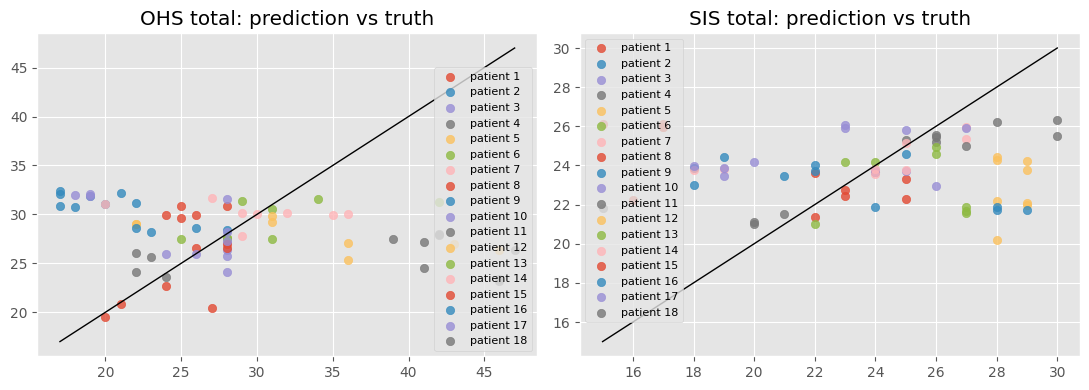

In [12]:
total_predictions = cv_predictions.groupby(["fold", "patient", "clinical_time", "history_days", "outcome"], as_index=False)[["truth", "prediction"]].sum()
total_metrics = grouped_metrics(total_predictions, ["outcome"])
display(total_metrics)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (outcome, frame) in zip(axes, total_predictions.groupby("outcome")):
    for patient, patient_frame in frame.groupby("patient"):
        ax.scatter(patient_frame["truth"], patient_frame["prediction"], label=f"patient {patient}", alpha=0.8)
    lo = min(frame["truth"].min(), frame["prediction"].min())
    hi = max(frame["truth"].max(), frame["prediction"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set_title(f"{outcome} total: prediction vs truth")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Item-level metrics match the multi-output training objective. Totals are reconstructed by summing predicted questionnaire items for a clinical-score view.

## Attention and Feature Weights

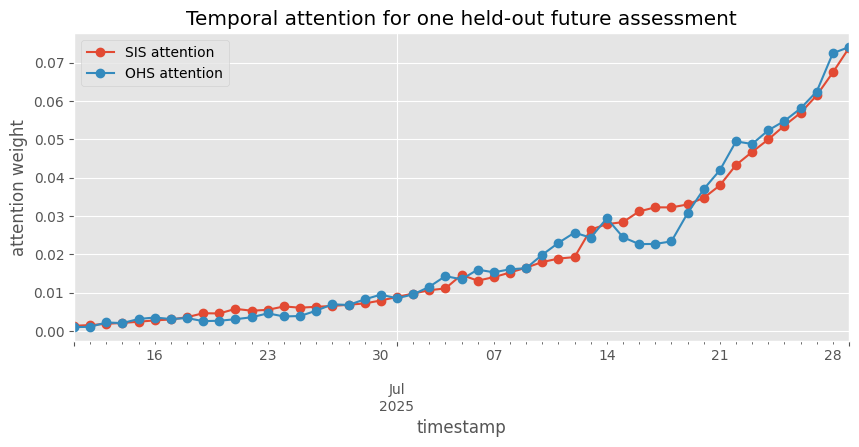

In [13]:
def attention_for_record(record, model, stats):
    batch = collate_forecasts([ForecastDataset([record], [0], stats)[0]])
    device_batch = move_batch(batch)
    model.eval()
    with torch.no_grad():
        output = model(device_batch["x"], device_batch["mask"], device_batch["lengths"])
    return pd.DataFrame({
        "timestamp": pd.to_datetime(record["timestamps"]),
        "SIS attention": output["sis_attention"][0, : len(record["timestamps"])].cpu().tolist(),
        "OHS attention": output["ohs_attention"][0, : len(record["timestamps"])].cpu().tolist(),
    })

attention_artifact = cv_artifacts[-1]
attention_record = examples[int(attention_artifact["test_ids"][-1])]
attention_df = attention_for_record(attention_record, attention_artifact["model"], attention_artifact["stats"])
fig, ax = plt.subplots(figsize=(10, 4))
attention_df.set_index("timestamp")[["SIS attention", "OHS attention"]].plot(ax=ax, marker="o")
ax.set_title("Temporal attention for one held-out future assessment")
ax.set_ylabel("attention weight")
plt.show()

In [14]:
weight_rows = []
for artifact in cv_artifacts:
    model = artifact["model"]
    with torch.no_grad():
        sis_learned = np.array(torch.nn.functional.softplus(model.sis_gate.raw).cpu().tolist())
        ohs_learned = np.array(torch.nn.functional.softplus(model.ohs_gate.raw).cpu().tolist())
    for feature, sis_weight, ohs_weight in zip(input_cols, sis_learned / sis_learned.mean(), ohs_learned / ohs_learned.mean()):
        weight_rows.append({"fold": artifact["fold"], "feature": feature, "SIS learned weight": sis_weight, "OHS learned weight": ohs_weight})

learned_weights = pd.DataFrame(weight_rows)
weight_summary = learned_weights.groupby("feature")[["SIS learned weight", "OHS learned weight"]].agg(["mean", "std"])
display(weight_summary.sort_values(("SIS learned weight", "mean"), ascending=False).head(12))
display(weight_summary.sort_values(("OHS learned weight", "mean"), ascending=False).head(12))

SIS learned weight           OHS learned weight  \
                                      mean       std               mean   
feature                                                                   
acceleration-mean                 3.849609  0.016540           7.264306   
sleep-deep                        3.151391  0.028628           3.626761   
sleep-snoring                     2.937282  0.021630           1.019503   
sleep-duration-to-sleep           2.343433  0.016408           0.613841   
sleep-light                       2.117177  0.018331           0.665537   
sleep-heartrate-max               1.850873  0.014489           0.601351   
motion-mean                       1.465540  0.016684           3.515705   
motion-count                      1.424077  0.015909           0.567180   
sleep-heartrate-min               1.352600  0.015703           0.577804   
heartrate-mean                    1.346058  0.014375           0.572138   
motion-max-timestamp              1.176596  0.019718           1.612825   
dow_cos                           1.014571  0.003819           1.014248   

                                   
                              std  
feature                            
acceleration-mean        0.047482  
sleep-deep               0.019907  
sleep-snoring            0.019156  
sleep-duration-to-sleep  0.007592  
sleep-light              0.004803  
sleep-heartrate-max      0.009145  
motion-mean              0.014880  
motion-count             0.007561  
sleep-heartrate-min      0.012373  
heartrate-mean           0.011855  
motion-max-timestamp     0.018185  
dow_cos                  0.006140

SIS learned weight           OHS learned weight          
                                   mean       std               mean       std
feature                                                                       
acceleration-mean              3.849609  0.016540           7.264306  0.047482
sleep-deep                     3.151391  0.028628           3.626761  0.019907
motion-mean                    1.465540  0.016684           3.515705  0.014880
motion-ratio                   0.641263  0.009939           2.277716  0.009442
motion-max                     0.551022  0.005463           1.907012  0.021149
motion-max-timestamp           1.176596  0.019718           1.612825  0.018185
step-mean                      0.640368  0.006327           1.152412  0.007375
sleep-heartrate-mean           0.636406  0.005045           1.030433  0.009788
sleep-rem                      0.877630  0.014055           1.021619  0.008687
sleep-snoring                  2.937282  0.021630           1.019503  0.019156
dow_cos                        1.014571  0.003819           1.014248  0.006140
dow_sin                        1.012656  0.012231           1.011439  0.012589

## Research Notes

- This is patient-grouped cross-validation on a very small sample. Report fold variation and patient-level metrics before clinical claims.
- Imputation, scaling, validation, and early stopping are refit inside each fold.
- The architecture can be replaced by a masked temporal transformer after the sample-construction and transform cells; those cells define the leakage boundary.